In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load PTB-XL metadata
df = pd.read_csv("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv")

df.head()


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [4]:
# Keep only rows with valid age and sex
df = df.dropna(subset=['age', 'sex'])

# Convert sex to readable format
df['sex'] = df['sex'].map({0: 'Male', 1: 'Female'})

df[['age', 'sex']].describe()


,age
count,21799.000000
mean,62.769301
std,32.308813
min,2.000000
25%,50.000000
50%,62.000000
75%,72.000000
max,300.000000


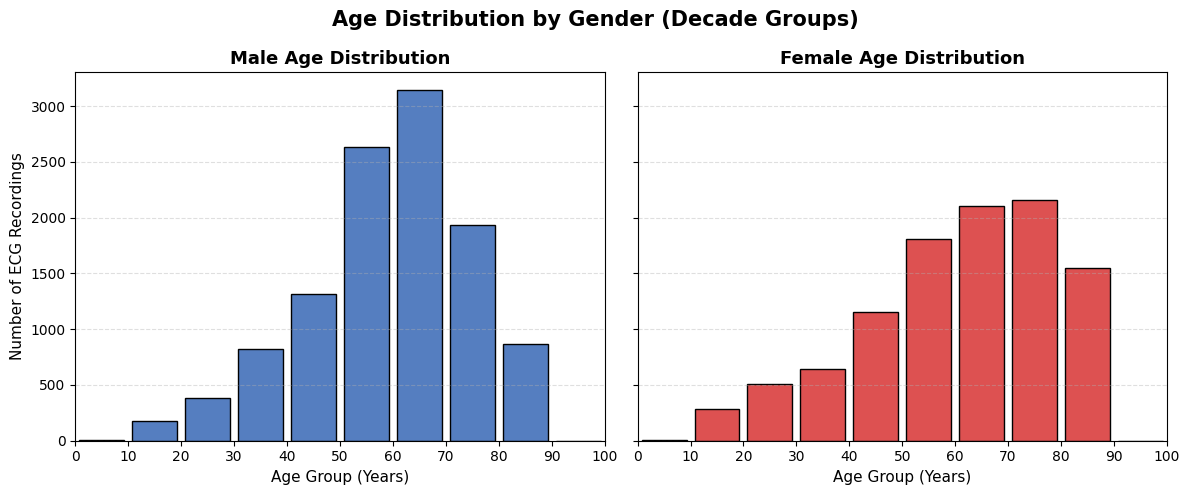

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure realistic age range
df = df[(df['age'] >= 0) & (df['age'] <= 100)]

# Age bins by decade
bins = np.arange(0, 110, 10)

male_age = df[df['sex'] == 'Male']['age']
female_age = df[df['sex'] == 'Female']['age']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Male Histogram (Blue)
axes[0].hist(
    male_age,
    bins=bins,
    edgecolor='black',
    rwidth=0.85,
    color="#557EC0FF"
)
axes[0].set_title("Male Age Distribution", fontsize=13, weight='bold')
axes[0].set_xlabel("Age Group (Years)", fontsize=11)
axes[0].set_ylabel("Number of ECG Recordings", fontsize=11)
axes[0].set_xticks(bins)
axes[0].set_xlim(0, 100)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Female Histogram (Orange)
axes[1].hist(
    female_age,
    bins=bins,
    edgecolor='black',
    rwidth=0.85,
    color="#DD5151"
)
axes[1].set_title("Female Age Distribution", fontsize=13, weight='bold')
axes[1].set_xlabel("Age Group (Years)", fontsize=11)
axes[1].set_xticks(bins)
axes[1].set_xlim(0, 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Age Distribution by Gender (Decade Groups)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


In [33]:
gender_percentage = df['sex'].value_counts(normalize=True) * 100

print("Gender Percentage (%):")
print(gender_percentage.round(2))


Gender Percentage (%):
sex
Male      52.48
Female    47.52
Name: proportion, dtype: float64


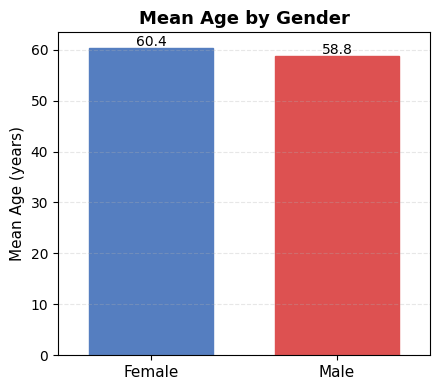

sex
Female    60.40
Male      58.76
Name: age, dtype: float64


In [26]:
mean_age = df.groupby('sex')['age'].mean().sort_index()

plt.figure(figsize=(4.5, 4))

# Better centered positions
x_positions = [0.3, 0.9]

bars = plt.bar(
    x_positions,
    mean_age.values,
    width=0.4,
    edgecolor='black',   # <-- Black border
    linewidth=1          # <-- Thickness of border
)

# Professional colors
bars[0].set_color("#557EC0FF")   # Male
bars[1].set_color("#DD5151")     # Female

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}",
        ha='center',
        fontsize=10
    )

# Clean x-axis labels
plt.xticks(x_positions, mean_age.index, fontsize=11)

plt.xlim(0, 1.2)

plt.ylabel("Mean Age (years)", fontsize=11)
plt.title("Mean Age by Gender", fontsize=13, weight='bold')

plt.ylim(0, max(mean_age.values) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("mean_age_by_gender.png", dpi=600, bbox_inches='tight')
plt.show()

print(mean_age.round(2))


In [35]:
summary_table = df.groupby('sex')['age'].agg(['count', 'mean', 'std', 'min', 'max'])

print("Demographic Summary Statistics:")
summary_table.round(2)


Demographic Summary Statistics:


,count,mean,std,min,max
sex,,,,,
Female,10220,60.40,18.03,3.0,89.0
Male,11286,58.76,15.48,2.0,89.0
